# Quick-look for KUL-TN-20 simulations

### Setup notebook

In [34]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [35]:
# Second part libraries
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [36]:
# Load data
idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1/000000001"
phot = LightCurve(idir, mode="multi")

In [37]:
# Unzip all compress files for the same star ID
phot.unpack()

In [38]:
# Fetch all feather filenames
filenames = phot.files("ftr")
print(filenames[0])

/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1/000000001/000000001_Ncam1.3_Q23.ftr


In [39]:
# Fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,index,time,flux,cx,cy,bg,flux_err,cx_err,cy_err,bg_err,chi2,iter,lamb
0,0,1.710720e+08,410229.540576,3.435027,3.190454,2071.866015,707.534999,0.000825,0.001052,13.981268,128.357663,4,1000.000000
1,1,1.710720e+08,410120.313730,3.435010,3.190033,2062.788650,707.635348,0.000825,0.001051,13.979921,134.175471,4,1000.000000
2,2,1.710721e+08,411317.396553,3.435469,3.191660,2050.002671,708.234683,0.000824,0.001049,13.957823,131.659457,5,11.111111
3,3,1.710721e+08,409155.972161,3.438362,3.195735,2067.549597,706.847671,0.000828,0.001053,13.979313,137.623449,5,11.111111
4,4,1.710721e+08,411133.853090,3.434571,3.194081,2082.123759,708.295445,0.000825,0.001051,13.996207,133.506084,5,0.012346


In [40]:
# Get target star information
star = lc.star_info(phot.files("cat")[0])
print(f"""
Pmag : {star[0]}
rOA  : {star[1]}
rCOB : {star[2]}
nCon : {star[3]}
rCon : {star[4]}
dMag : {star[5]}
SPR  : {star[6]}
""")


Pmag : 9.94
rOA  : 10.66848822911957
rCOB : 0.053303083915871526
nCon : 3
rCon : 3.0263113114087274
dMag : 3.9800000000000004
SPR  : 0.456589930192956



<IPython.core.display.Javascript object>


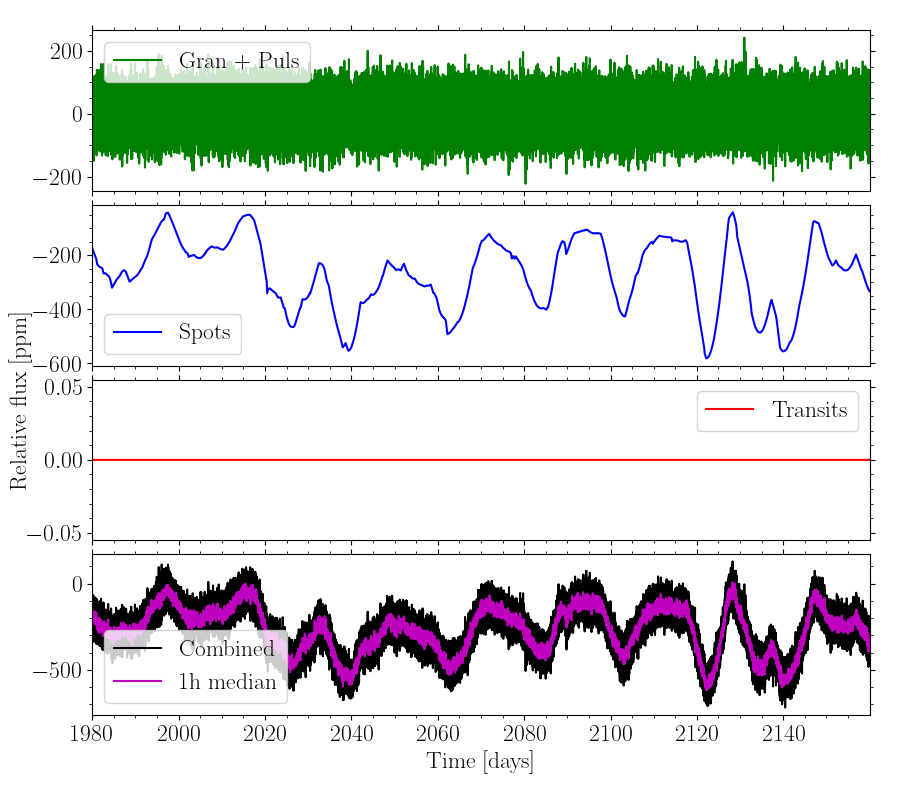

In [41]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource(figsize=(9,8));

<IPython.core.display.Javascript object>


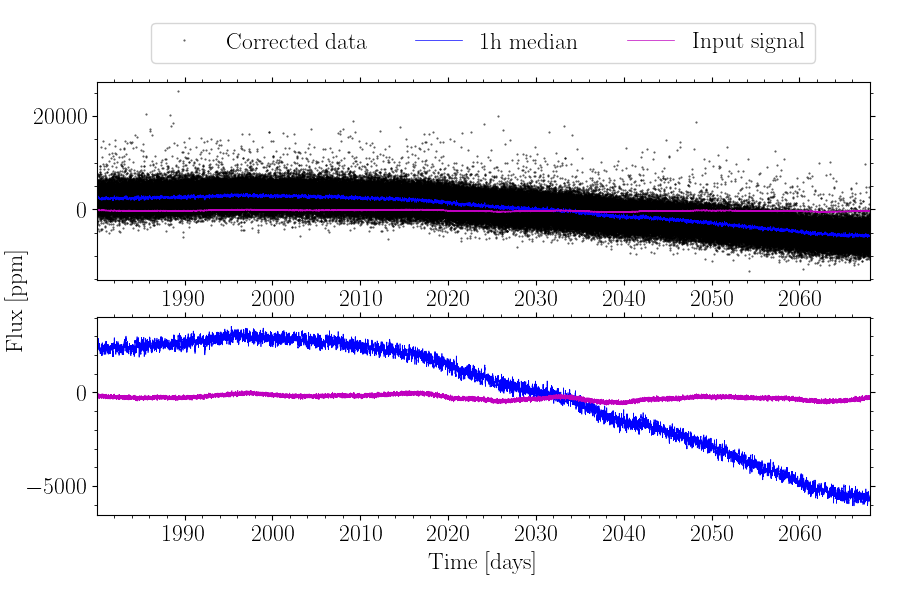

In [42]:
# Plot a quick O-C comparison plot 
fig, ax = lc.plot_oc();

<IPython.core.display.Javascript object>


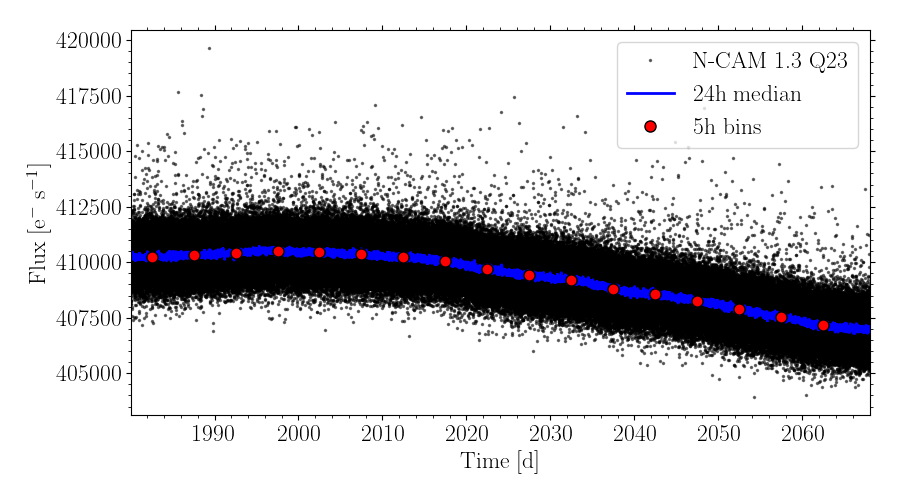

In [43]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=24, figsize=(9,5));

In [44]:
# Fetch the NSR per 1h 
lc.getNSR()

149.86026888121876